In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler

In [2]:
df_test = pd.read_csv('alzheimers_disease_data.csv')

In [3]:
cols = df_test.columns.tolist()
target_col ='Diagnosis'
cols.remove(target_col)
cols.append(target_col)
df_reordered = df_test[cols]
df_test = df_reordered




In [4]:
df_test = df_test.drop(['DoctorInCharge'], axis=1, errors='ignore')


In [5]:
df_test.head()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,6.518877,0,0,1.725883,0,0,0,1,0,0
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,7.118696,0,0,2.592424,0,0,0,0,1,0
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,5.895077,0,0,7.119548,0,1,0,1,0,0
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,8.965106,0,1,6.481226,0,0,0,0,0,0
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,6.045039,0,0,0.014691,0,0,1,1,0,0


In [6]:
df_test.tail()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
2144,6895,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,...,0.238667,0,0,4.492838,1,0,0,0,0,1
2145,6896,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,...,8.687480,0,1,9.204952,0,0,0,0,0,1
2146,6897,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,...,1.972137,0,0,5.036334,0,0,0,0,0,1
2147,6898,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,...,5.173891,0,0,3.785399,0,0,0,0,1,1
2148,6899,72,0,0,2,33.289738,0,7.890703,6.570993,7.941404,...,6.307543,0,1,8.327563,0,1,0,0,1,0


In [7]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 34 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [8]:
df_test.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


Text(0.5, 1.0, 'Count plot of Diagnosis')

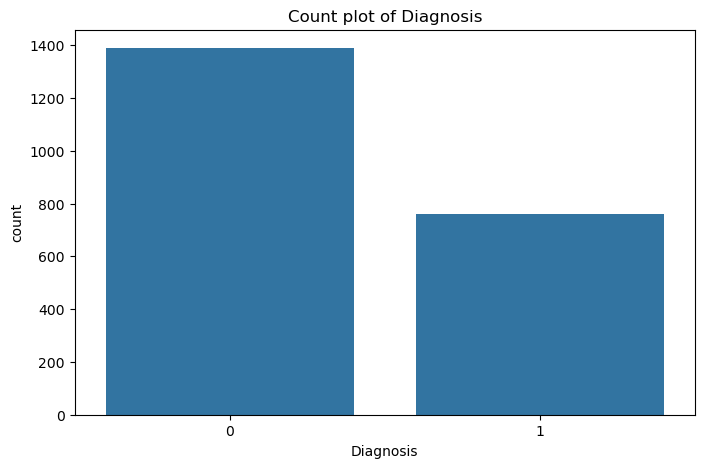

In [9]:
plt.figure(figsize = (8,5))
sns.countplot(data = df_test , x = df_test['Diagnosis'])
plt.title("Count plot of Diagnosis")

Text(0.5, 1.0, 'Distribution of Age vs Diagnosis')

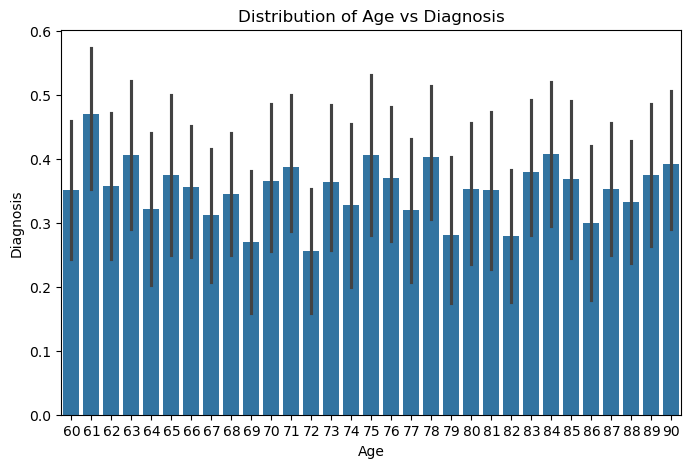

In [10]:
plt.figure(figsize = (8 , 5))
sns.barplot(data = df_test ,x ="Age" , y = "Diagnosis" )
plt.title("Distribution of Age vs Diagnosis")

Text(0.5, 1.0, 'Distribution of Gender vs Diagnosis')

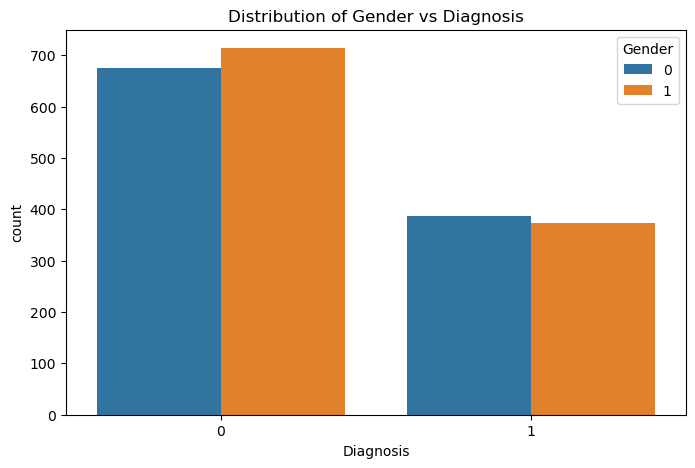

In [11]:
plt.figure(figsize = (8 , 5))
sns.countplot(data = df_test , x = "Diagnosis" , hue = "Gender")
plt.title("Distribution of Gender vs Diagnosis")

Text(0.5, 1.0, 'Distribution of EducationLevel vs Diagnosis')

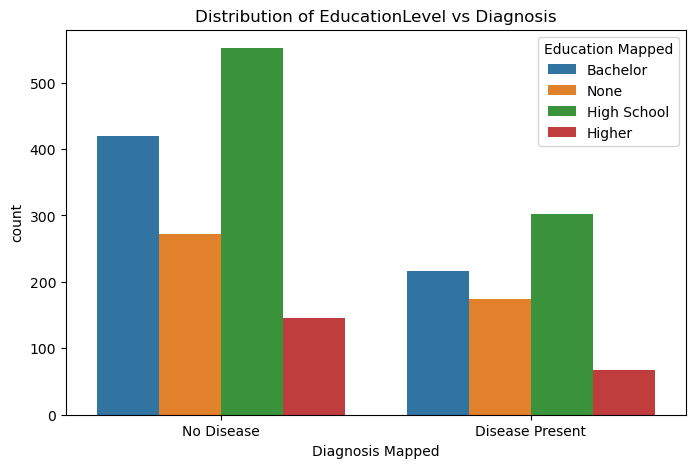

In [12]:

plt.figure(figsize = (8 , 5))

diagnosis_labels = ['No Disease', 'Disease Present'] # Adjust based on your actual data
education_labels = ['None', 'High School', 'Bachelor', 'Higher'] 

df_test['Diagnosis Mapped'] = df_test['Diagnosis'].map({i: label for i, label in enumerate(diagnosis_labels)})
df_test['Education Mapped'] = df_test['EducationLevel'].map({i: label for i, label in enumerate(education_labels)})


sns.countplot(data = df_test , x = "Diagnosis Mapped" , hue = "Education Mapped")
plt.title("Distribution of EducationLevel vs Diagnosis")

Text(0.5, 1.0, 'Distribution of Family History vs Diagnosis')

<Figure size 800x500 with 0 Axes>

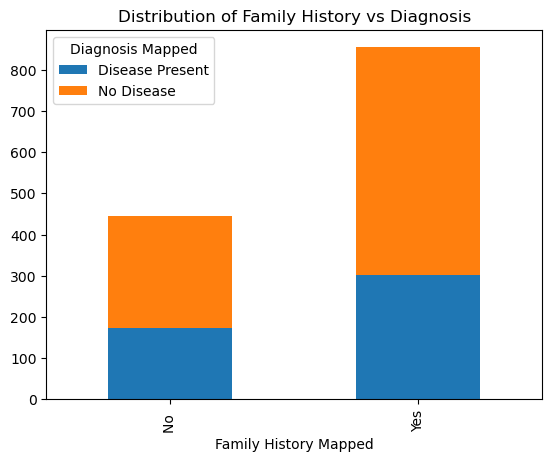

In [13]:
plt.figure(figsize = (8 , 5))

diagnosis_labels = ['No Disease', 'Disease Present'] # Adjust based on your actual data
Familyhistory_label = ['No ', 'Yes'] 

df_test['Diagnosis Mapped'] = df_test['Diagnosis'].map({i: label for i, label in enumerate(diagnosis_labels)})
df_test['Family History Mapped'] = df_test['EducationLevel'].map({i: label for i, label in enumerate(Familyhistory_label)})

pd.crosstab(df_test['Family History Mapped'], df_test['Diagnosis Mapped']).plot(kind='bar', stacked=True)
plt.title("Distribution of Family History vs Diagnosis")

Text(0.5, 1.0, 'Diagnosis VS BMI')

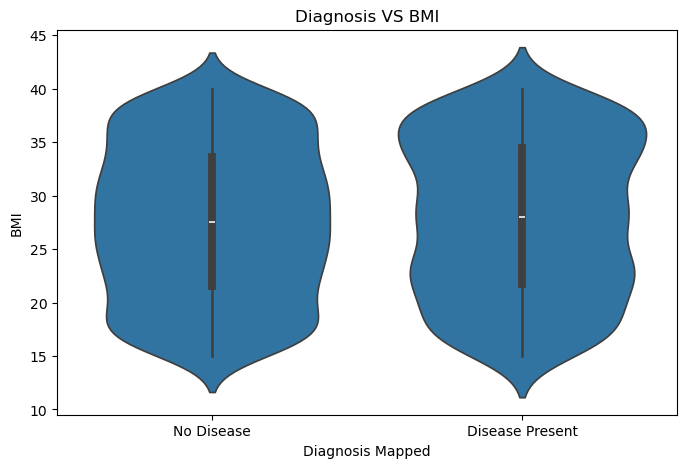

In [14]:
plt.figure(figsize = (8 , 5))

diagnosis_labels = ['No Disease', 'Disease Present'] # Adjust based on your actual data


df_test['Diagnosis Mapped'] = df_test['Diagnosis'].map({i: label for i, label in enumerate(diagnosis_labels)})


sns.violinplot(data = df_test , x = 'Diagnosis Mapped' , y = 'BMI')
plt.title("Diagnosis VS BMI")

Text(0.5, 1.0, 'Smoking vs Diagnosis')

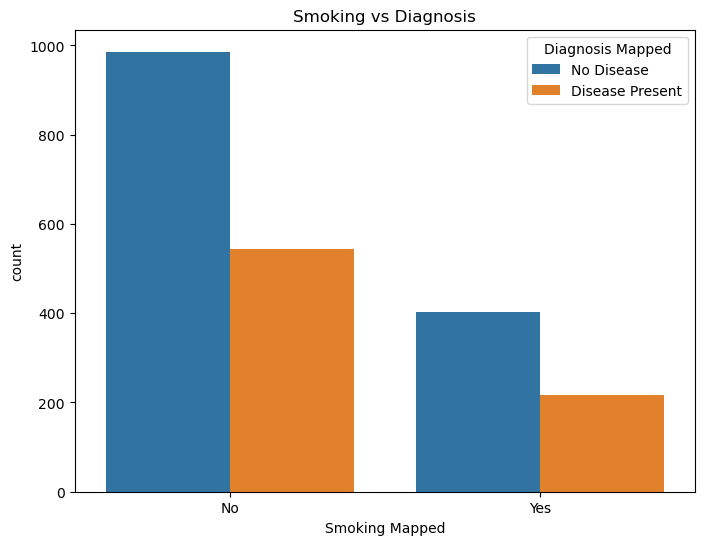

In [15]:
plt.figure(figsize = (8 ,6))
diagnosis_labels = ['No Disease' , 'Disease Present']
smoking_labeles = ['No' , 'Yes']

df_test['Diagnosis Mapped'] = df_test['Diagnosis'].map({i: label for i, label in enumerate(diagnosis_labels)})
df_test['Smoking Mapped'] = df_test['Smoking'].map({i: label for i, label in enumerate(smoking_labeles)})
sns.countplot(data = df_test , x = "Smoking Mapped" , hue="Diagnosis Mapped")
plt.title("Smoking vs Diagnosis")

Text(0.5, 1.0, 'Sleep vs Diagnosis')

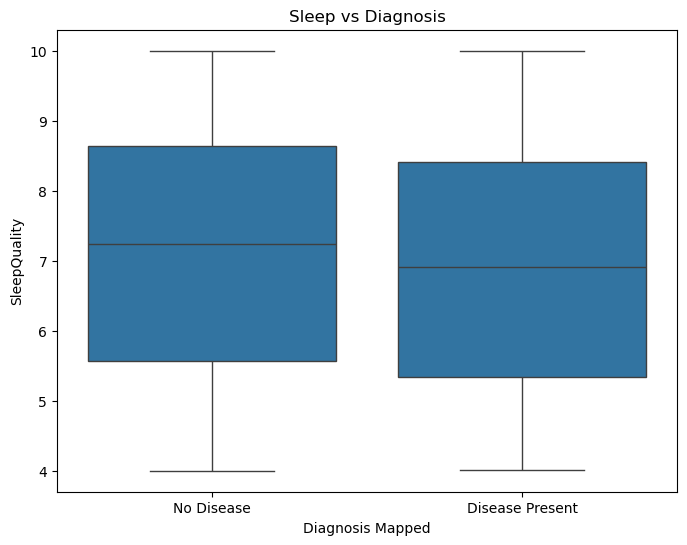

In [16]:

plt.figure(figsize = (8 ,6))
diagnosis_labels = ['No Disease', 'Disease Present'] # Adjust based on your actual data


df_test['Diagnosis Mapped'] = df_test['Diagnosis'].map({i: label for i, label in enumerate(diagnosis_labels)})


sns.boxplot(data = df_test , x = 'Diagnosis Mapped' , y = 'SleepQuality')
plt.title("Sleep vs Diagnosis")

Text(0.5, 1.0, 'DiastolicBP vs Diagnosis')

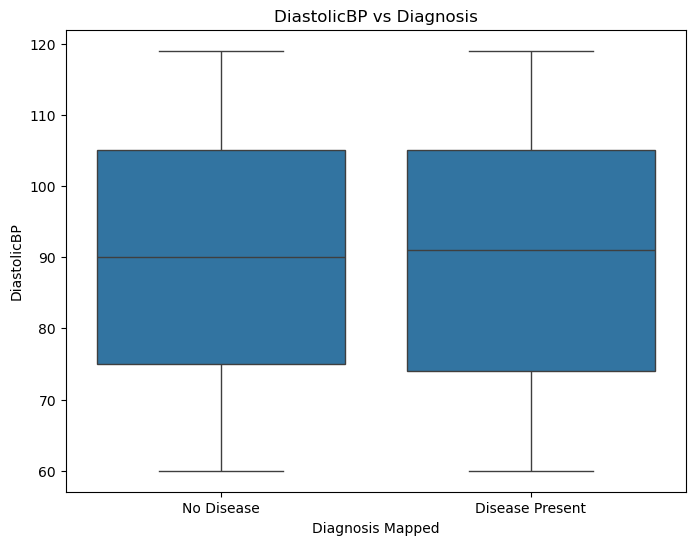

In [17]:
plt.figure(figsize = (8 ,6))
diagnosis_labels = ['No Disease', 'Disease Present'] # Adjust based on your actual data


df_test['Diagnosis Mapped'] = df_test['Diagnosis'].map({i: label for i, label in enumerate(diagnosis_labels)})


sns.boxplot(data = df_test , x = 'Diagnosis Mapped' , y = 'DiastolicBP')
plt.title("DiastolicBP vs Diagnosis")

Text(0.5, 1.0, 'SystoicBP vs Diagnosis')

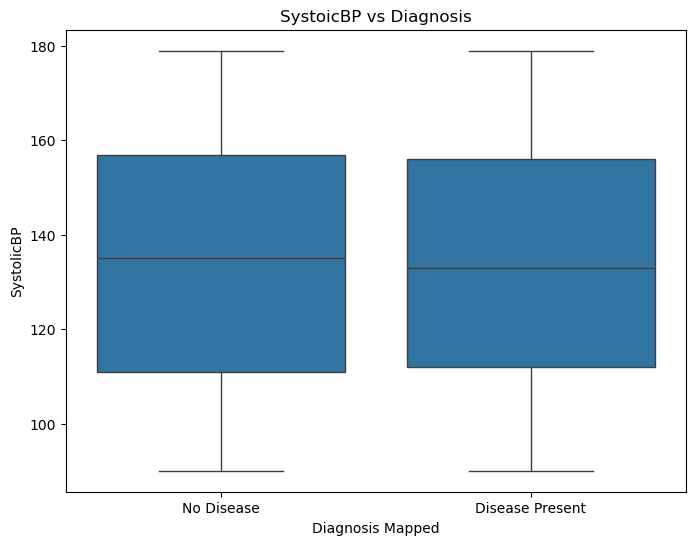

In [18]:
plt.figure(figsize = (8 ,6))
diagnosis_labels = ['No Disease', 'Disease Present'] # Adjust based on your actual data


df_test['Diagnosis Mapped'] = df_test['Diagnosis'].map({i: label for i, label in enumerate(diagnosis_labels)})


sns.boxplot(data = df_test , x = 'Diagnosis Mapped' , y = 'SystolicBP')
plt.title("SystoicBP vs Diagnosis")

<Figure size 800x600 with 0 Axes>

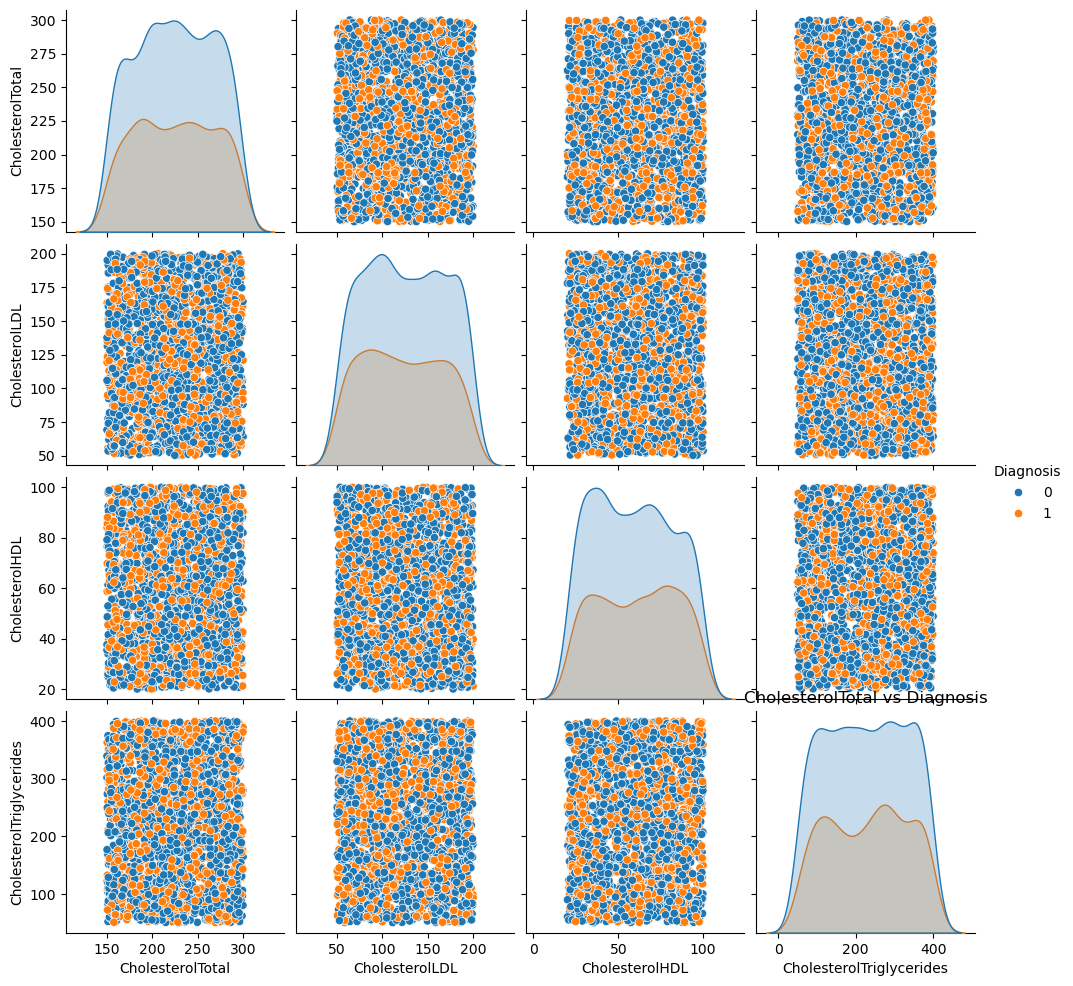

<Figure size 800x600 with 0 Axes>

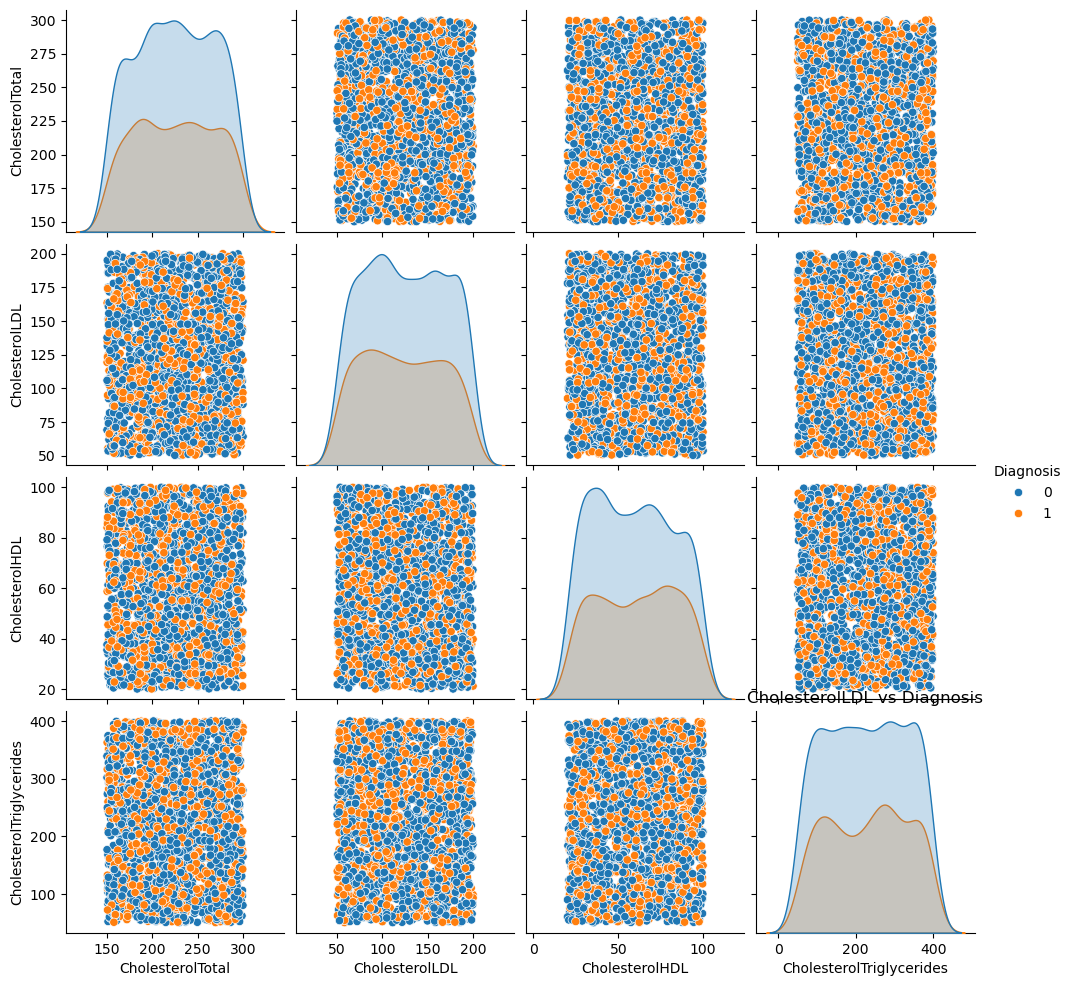

<Figure size 800x600 with 0 Axes>

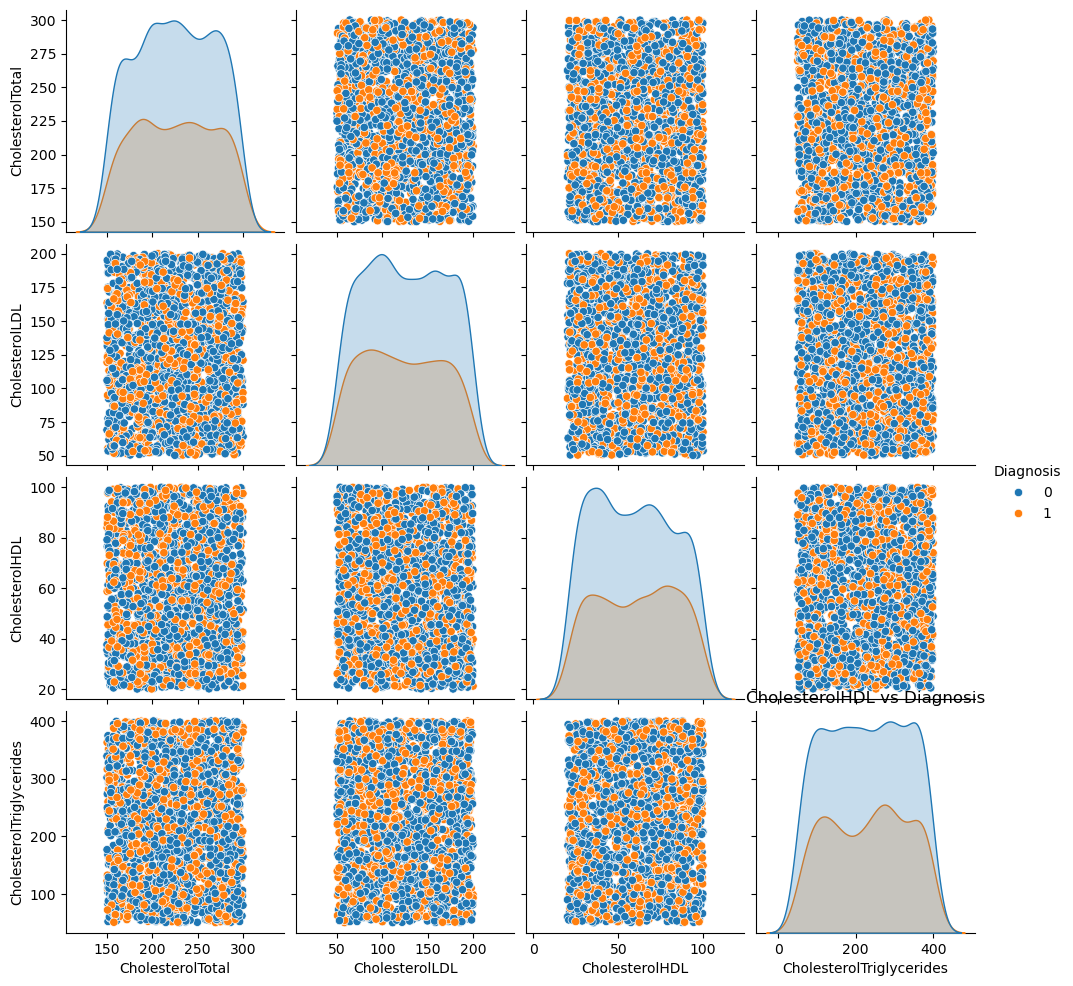

<Figure size 800x600 with 0 Axes>

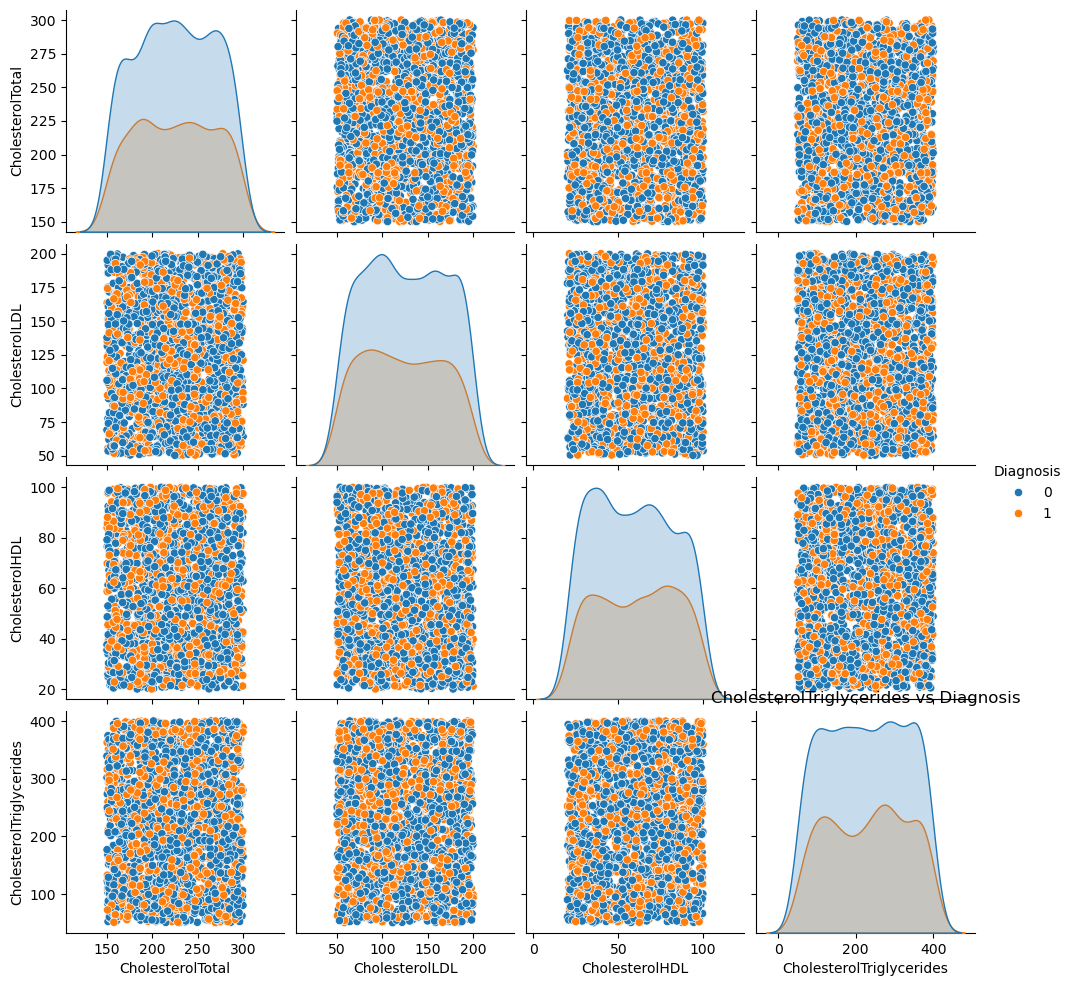

In [19]:
cholesterol_cols = ['CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides']

for col in cholesterol_cols:
    plt.figure(figsize = (8 , 6))
    diagnosis_labels = ['No Disease', 'Disease Present'] # Adjust based on your actual data
    df_test['Diagnosis Mapped'] = df_test['Diagnosis'].map({i: label for i, label in enumerate(diagnosis_labels)})
    sns.pairplot(data = df_test, hue='Diagnosis', vars=cholesterol_cols)
    plt.title(f'{col} vs Diagnosis')
    plt.show()
        
        




    

Text(0.5, 1.0, 'SystoicBP vs Diagnosis')

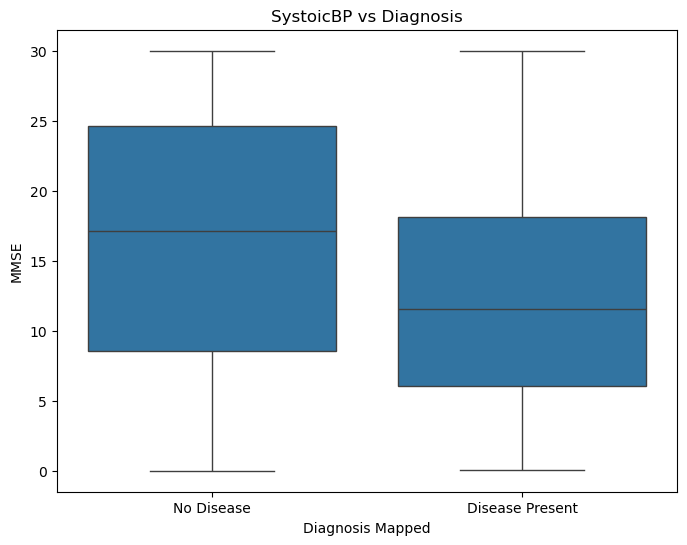

In [20]:
plt.figure(figsize = (8 ,6))
diagnosis_labels = ['No Disease', 'Disease Present'] # Adjust based on your actual data


df_test['Diagnosis Mapped'] = df_test['Diagnosis'].map({i: label for i, label in enumerate(diagnosis_labels)})


sns.boxplot(data = df_test , x = 'Diagnosis Mapped' , y = 'MMSE')
plt.title("SystoicBP vs Diagnosis")

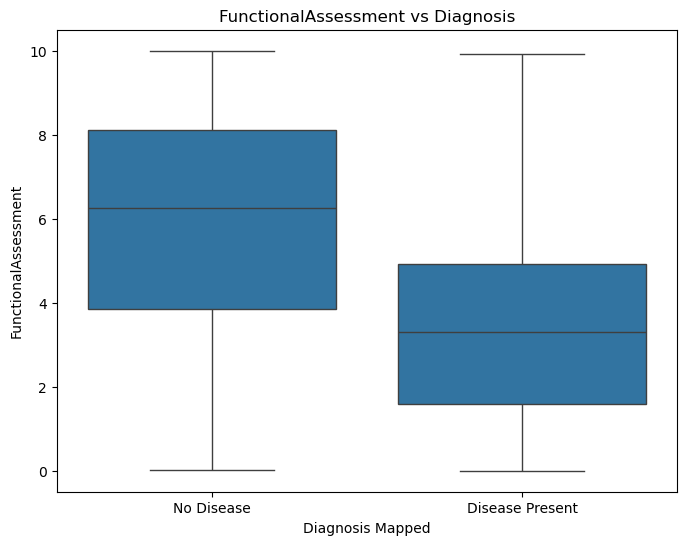

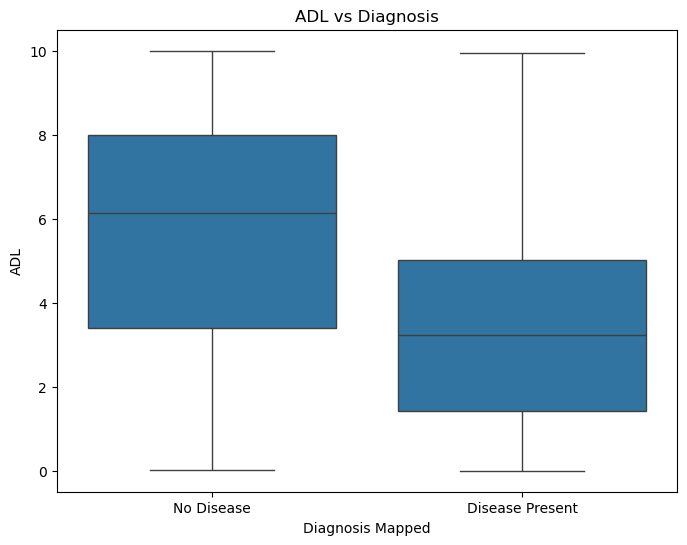

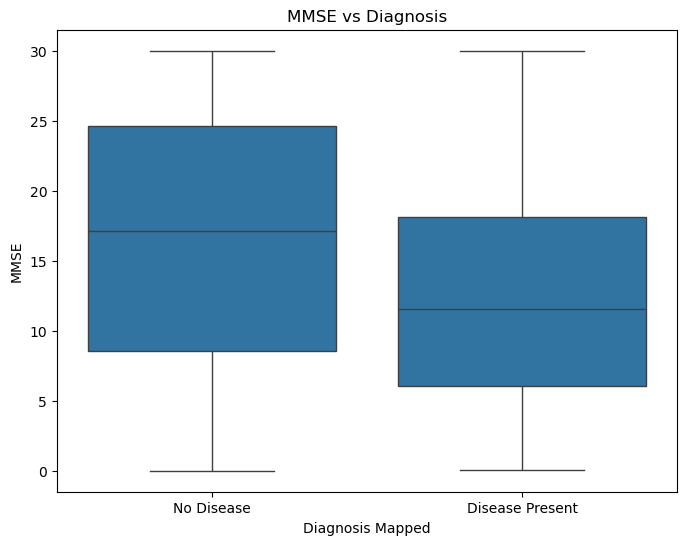

In [21]:
Functionals_cols = ['FunctionalAssessment', 'ADL' , 'MMSE']

for col in Functionals_cols:
    plt.figure(figsize = (8 , 6))
    diagnosis_labels = ['No Disease', 'Disease Present'] # Adjust based on your actual data
    df_test['Diagnosis Mapped'] = df_test['Diagnosis'].map({i: label for i, label in enumerate(diagnosis_labels)})
    sns.boxplot(data = df_test, x='Diagnosis Mapped', y = col)
    plt.title(f'{col} vs Diagnosis')
    plt.show()

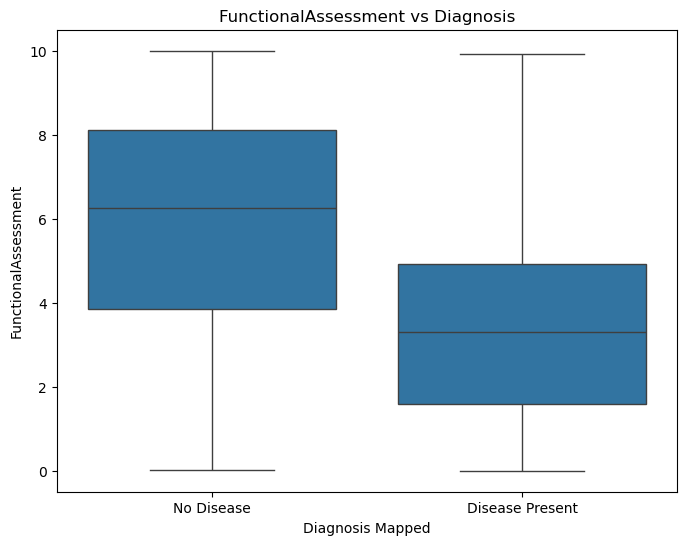

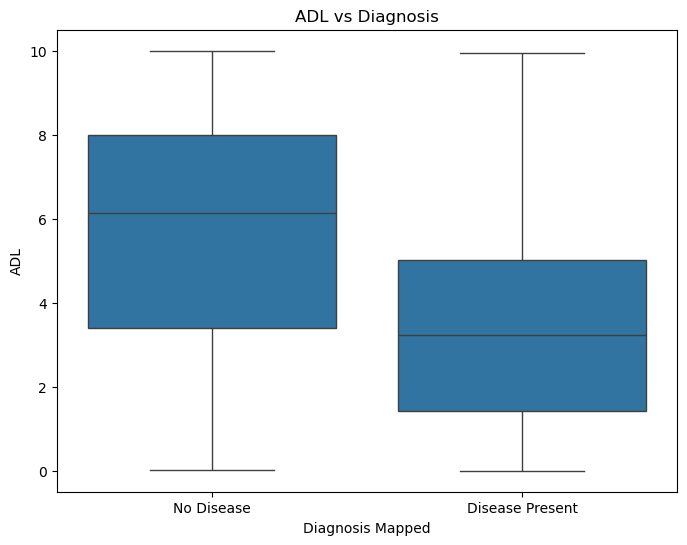

In [22]:
Functionals_cols = ['FunctionalAssessment', 'ADL']

for col in Functionals_cols:
    plt.figure(figsize = (8 , 6))
    diagnosis_labels = ['No Disease', 'Disease Present'] # Adjust based on your actual data
    df_test['Diagnosis Mapped'] = df_test['Diagnosis'].map({i: label for i, label in enumerate(diagnosis_labels)})
    sns.boxplot(data = df_test, x='Diagnosis Mapped', y = col)
    plt.title(f'{col} vs Diagnosis')
    plt.show()

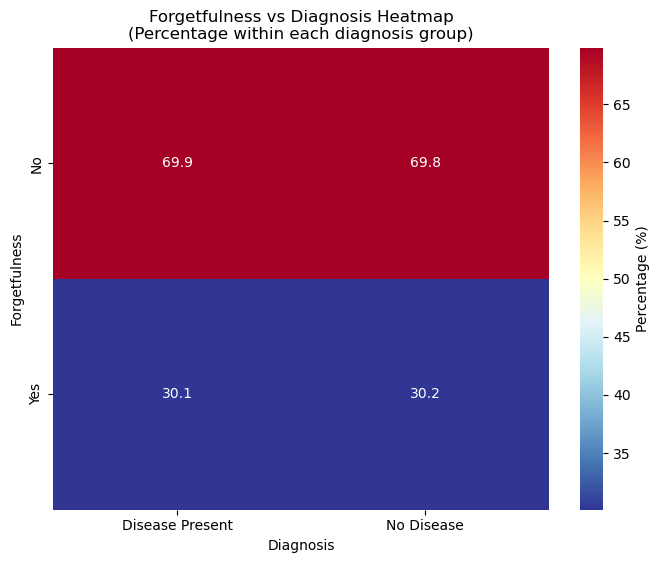

In [23]:


# Setup the data mapping
Memory_Behavioral_Symptoms_cols = {
    'Forgetfulness': ['No', 'Yes'],
    'Disorientation': ['No', 'Yes'],
    'PersonalityChanges': ['No', 'Yes']
}

diagnosis_labels = ['No Disease', 'Disease Present']

# Map the values
df_test['Diagnosis Mapped'] = df_test['Diagnosis'].map({i: label for i, label in enumerate(diagnosis_labels)})
df_test['Forgetfulness Mapped'] = df_test['Forgetfulness'].map({i: label for i, label in enumerate(Memory_Behavioral_Symptoms_cols['Forgetfulness'])})


# METHOD 2: Heatmap showing the relationship
plt.figure(figsize=(8, 6))

# Create a proper crosstab for heatmap
crosstab_counts = pd.crosstab(df_test['Forgetfulness Mapped'], df_test['Diagnosis Mapped'])
crosstab_pct_heatmap = pd.crosstab(df_test['Forgetfulness Mapped'], df_test['Diagnosis Mapped'], normalize='columns') * 100

sns.heatmap(crosstab_pct_heatmap, annot=True, cmap='RdYlBu_r', fmt='.1f', 
           cbar_kws={'label': 'Percentage (%)'})
plt.title('Forgetfulness vs Diagnosis Heatmap\n(Percentage within each diagnosis group)')
plt.ylabel('Forgetfulness')
plt.xlabel('Diagnosis')
plt.show()



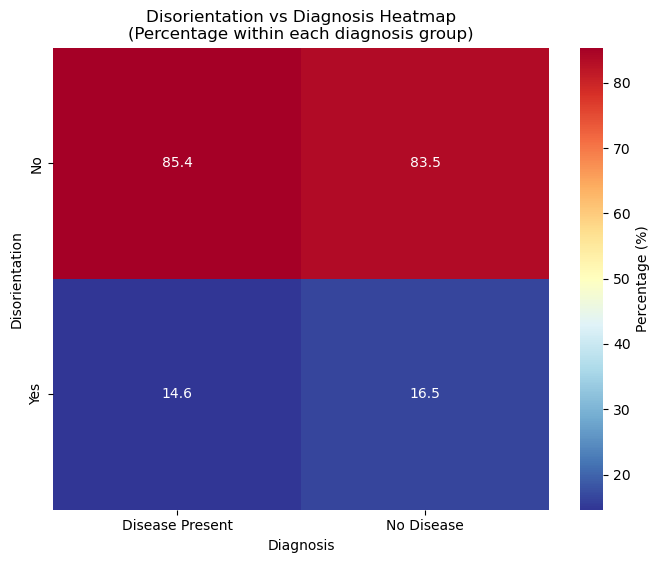

In [24]:
# Setup the data mapping
Memory_Behavioral_Symptoms_cols = {
    'Forgetfulness': ['No', 'Yes'],
    'Disorientation': ['No', 'Yes'],
    'PersonalityChanges': ['No', 'Yes']
}

diagnosis_labels = ['No Disease', 'Disease Present']

# Map the values
df_test['Diagnosis Mapped'] = df_test['Diagnosis'].map({i: label for i, label in enumerate(diagnosis_labels)})
df_test['Disorientation Mapped'] = df_test['Disorientation'].map({i: label for i, label in enumerate(Memory_Behavioral_Symptoms_cols['Forgetfulness'])})


# METHOD 2: Heatmap showing the relationship
plt.figure(figsize=(8, 6))

# Create a proper crosstab for heatmap
crosstab_counts = pd.crosstab(df_test['Disorientation Mapped'], df_test['Diagnosis Mapped'])
crosstab_pct_heatmap = pd.crosstab(df_test['Disorientation Mapped'], df_test['Diagnosis Mapped'], normalize='columns') * 100

sns.heatmap(crosstab_pct_heatmap, annot=True, cmap='RdYlBu_r', fmt='.1f', 
           cbar_kws={'label': 'Percentage (%)'})
plt.title('Disorientation vs Diagnosis Heatmap\n(Percentage within each diagnosis group)')
plt.ylabel('Disorientation')
plt.xlabel('Diagnosis')
plt.show()



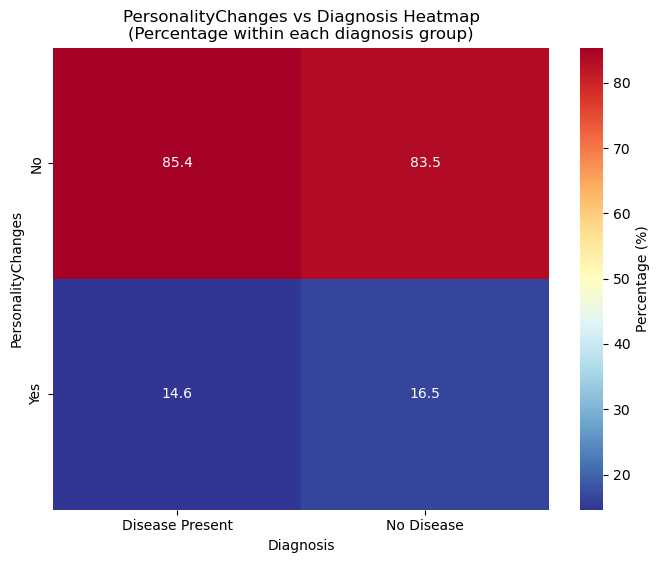

In [25]:
# Setup the data mapping
Memory_Behavioral_Symptoms_cols = {
    'Forgetfulness': ['No', 'Yes'],
    'Disorientation': ['No', 'Yes'],
    'PersonalityChanges': ['No', 'Yes']
}

diagnosis_labels = ['No Disease', 'Disease Present']

# Map the values
df_test['Diagnosis Mapped'] = df_test['Diagnosis'].map({i: label for i, label in enumerate(diagnosis_labels)})
df_test['PersonalityChanges Mapped'] = df_test['Disorientation'].map({i: label for i, label in enumerate(Memory_Behavioral_Symptoms_cols['Forgetfulness'])})


# METHOD 2: Heatmap showing the relationship
plt.figure(figsize=(8, 6))

# Create a proper crosstab for heatmap
crosstab_counts = pd.crosstab(df_test['PersonalityChanges Mapped'], df_test['Diagnosis Mapped'])
crosstab_pct_heatmap = pd.crosstab(df_test['PersonalityChanges Mapped'], df_test['Diagnosis Mapped'], normalize='columns') * 100

sns.heatmap(crosstab_pct_heatmap, annot=True, cmap='RdYlBu_r', fmt='.1f', 
           cbar_kws={'label': 'Percentage (%)'})
plt.title('PersonalityChanges vs Diagnosis Heatmap\n(Percentage within each diagnosis group)')
plt.ylabel('PersonalityChanges')
plt.xlabel('Diagnosis')
plt.show()